In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score

In [ ]:
#Load Processed Dataset
df = pd.read_csv("processed_data.csv")

df.head()

,customer_id,product_id,quantity,price,transaction_date,payment_method,store_location,product_category,discount,total_amount
0,109318,C,7,80.079844,26-12-2023 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,05-08-2023 00:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,11-03-2024 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,27-10-2023 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,22-12-2023 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484


In [ ]:
print(df.columns)

Index(['customer_id', 'product_id', 'quantity', 'price', 'transaction_date',
       'payment_method', 'store_location', 'product_category', 'discount',
       'total_amount'],
      dtype='object')


In [ ]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

/tmp/ipykernel_388/3937442087.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['transaction_date'] = pd.to_datetime(df['transaction_date'])


In [ ]:
today = df['transaction_date'].max() + pd.Timedelta(days=1)

In [ ]:
rfm = df.groupby('customer_id').agg({
    'transaction_date': lambda x: (today - x.max()).days,
    'customer_id': 'count',
    'total_amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.reset_index(inplace=True)

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,49,329,1,21.399047
1,100,352,1,710.062576
2,169,89,1,457.119532
3,213,308,1,340.479447
4,227,280,1,348.246094


In [ ]:
X = rfm[['Recency', 'Frequency', 'Monetary']]

In [ ]:
#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

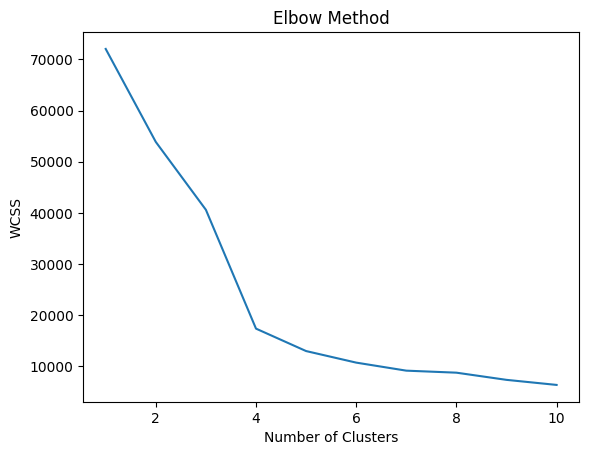

In [ ]:
#Elbow Method (Find Optimal K)
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
#K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

print("Silhouette Score:",
      silhouette_score(X_scaled, rfm['Cluster_KMeans']))

Silhouette Score: 0.42702063947460417


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score}")

K = 2, Silhouette Score = 0.34639389783472846
K = 3, Silhouette Score = 0.39111916306200617
K = 4, Silhouette Score = 0.42702063947460417
K = 5, Silhouette Score = 0.42018637041734314


Cluster Selection

The optimal number of clusters was determined using the Silhouette Score method.

Silhouette scores were computed for different values of K ranging from 2 to 5. The highest score was observed at K = 4 (0.427), indicating better-defined and well-separated clusters compared to other values.

Although K = 5 also showed a competitive score, K = 4 was selected as the optimal number of clusters due to its maximum silhouette value and better cluster stability.

In [ ]:
#Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
rfm['Cluster_Hierarchical'] = hc.fit_predict(X_scaled)
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, rfm['Cluster_Hierarchical'])
print("Silhouette Score (Hierarchical):", score)

Silhouette Score (Hierarchical): 0.3285993334572866


In [ ]:
#DBScan
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

# Check clusters
print("Unique clusters (DBSCAN):", set(rfm['Cluster_DBSCAN']))

# Silhouette Score (only if valid clusters exist)
if len(set(rfm['Cluster_DBSCAN'])) > 1 and -1 not in set(rfm['Cluster_DBSCAN']):
    print("Silhouette Score (DBSCAN):", silhouette_score(X_scaled, rfm['Cluster_DBSCAN']))
else:
    print("DBSCAN includes noise (-1) or only one cluster, silhouette may not be valid")

Unique clusters (DBSCAN): {0, 1, 2, -1}
DBSCAN includes noise (-1) or only one cluster, silhouette may not be valid


In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
rfm['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

print(set(rfm['Cluster_DBSCAN']))

{0, 1}


In [ ]:
#GMM
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Apply GMM
gmm = GaussianMixture(n_components=4, random_state=42)
rfm['Cluster_GMM'] = gmm.fit_predict(X_scaled)

# Silhouette Score
print("Silhouette Score (GMM):", silhouette_score(X_scaled, rfm['Cluster_GMM']))

Silhouette Score (GMM): 0.4144127691046873


In [ ]:
#Compare Results
print(rfm[['Cluster_KMeans', 'Cluster_Hierarchical',
          'Cluster_DBSCAN', 'Cluster_GMM']].head())

   Cluster_KMeans  Cluster_Hierarchical  Cluster_DBSCAN  Cluster_GMM
0               2                     1               0            2
1               0                     2               0            0
2               0                     0               0            0
3               2                     2               0            0
4               2                     2               0            0


In [ ]:

df.to_csv("clustering_results.csv", index=False)